# Crop Recommendation Dataset
EDA + ML  from this Kaggle dataset:

https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset/data

Precision agirculture is in trend nowadays. Precision agriculture is a modern farming technique that uses the data of soil charachteristics, soil types, crop yield data, weather conditions and suggests the farmers with the most optimal crop to grow in their farms for maximum yield and profit. This technique can reduce the crop failures and will help the farmers to take informed decision about their farming strategy, it provides a new tool for Oryza-Mind Agent in order to tell user waht crop type fits best on his soil.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

In [4]:
PATH = '/content/Crop_recommendation.csv'
df = pd.read_csv(PATH)

In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
df.shape

(2200, 8)

In [7]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [8]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [9]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [10]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [13]:
features = df[['N', 'P','K','temperature', 'humidity', 'ph', 'rainfall']]
target = df['label']
labels = df['label']

In [21]:
from sklearn.preprocessing import LabelEncoder


In [14]:
RANDOM_STATE = 42

In [22]:
from sklearn.model_selection import train_test_split

In [23]:

Xtrain, Xtest, Ytrain, Ytest = train_test_split(features,target,
                                                test_size = 0.2,
                                                random_state =RANDOM_STATE)

In [24]:

le = LabelEncoder()
Ytrain = le.fit_transform(Ytrain)
Ytest = le.transform(Ytest)

In [80]:
features = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]

In [78]:
correlation_matrix = df.corr(numeric_only=True)

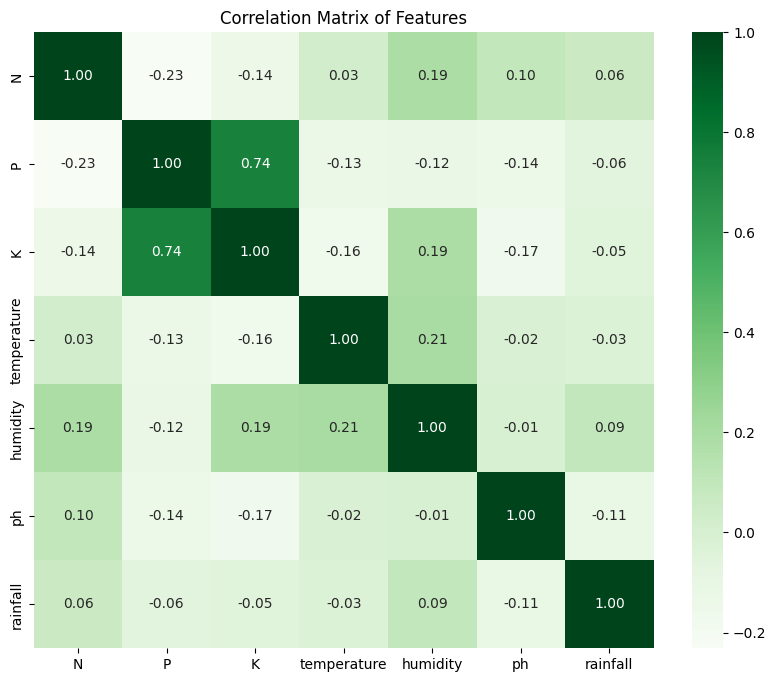

In [79]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
RF = RandomForestClassifier(n_estimators=30, max_depth=4, min_samples_leaf=200, random_state=RANDOM_STATE)

In [56]:
RF.fit(Xtrain,Ytrain)

RandomForestClassifier(max_depth=4, min_samples_leaf=200, n_estimators=30,
                       random_state=42)

In [57]:
predicted_values = RF.predict(Xtest)

In [58]:
x = metrics.accuracy_score(Ytest, predicted_values)

In [59]:
print("RF's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

RF's Accuracy is:  0.8159090909090909
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        23
           1       0.84      1.00      0.91        21
           2       0.80      0.80      0.80        20
           3       1.00      0.96      0.98        26
           4       1.00      0.96      0.98        27
           5       1.00      0.94      0.97        17
           6       0.77      1.00      0.87        17
           7       0.70      1.00      0.82        14
           8       1.00      0.13      0.23        23
           9       0.69      1.00      0.82        20
          10       0.44      1.00      0.61        11
          11       0.94      0.76      0.84        21
          12       1.00      0.95      0.97        19
          13       1.00      0.42      0.59        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       0.82      1.00      0.90

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [60]:
score = cross_val_score(RF,features,target,cv=5)
score

array([0.86363636, 0.86363636, 0.87272727, 0.82272727, 0.85227273])

In [61]:
from sklearn.model_selection import GridSearchCV


In [62]:

# Encode the full target variable for GridSearchCV
le_full = LabelEncoder()
target_encoded = le_full.fit_transform(target)


In [64]:

# Define the parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 150, 200], # Number of trees in the forest
    'max_depth': [5, 10, 15, 20 ],    # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4, 8], # Minimum number of samples required to be at a leaf node
}


In [65]:
# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)



In [66]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')


In [67]:

# Fit GridSearchCV to the data
grid_search.fit(features, target_encoded)



Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='accuracy', verbose=2)

In [68]:
# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Best parameters found:  {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 50}
Best accuracy found:  0.9949999999999999


## Save best Model

In [70]:
import joblib

In [71]:
# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

In [72]:
# Make predictions on the test set with the best model
best_predicted_values = best_rf_model.predict(Xtest)

In [73]:
# Evaluate the best model
best_accuracy = metrics.accuracy_score(Ytest, best_predicted_values)
print(f"Best Model Accuracy on Test Set: {best_accuracy:.4f}")
print("\nClassification Report for Best Model:")
print(classification_report(Ytest, best_predicted_values))

Best Model Accuracy on Test Set: 1.0000

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
  

In [84]:
y_pred = best_rf_model.predict(Xtest)
y_true = Ytest

In [85]:

from sklearn.metrics import confusion_matrix


In [86]:
cm_knn = confusion_matrix(y_true,y_pred)

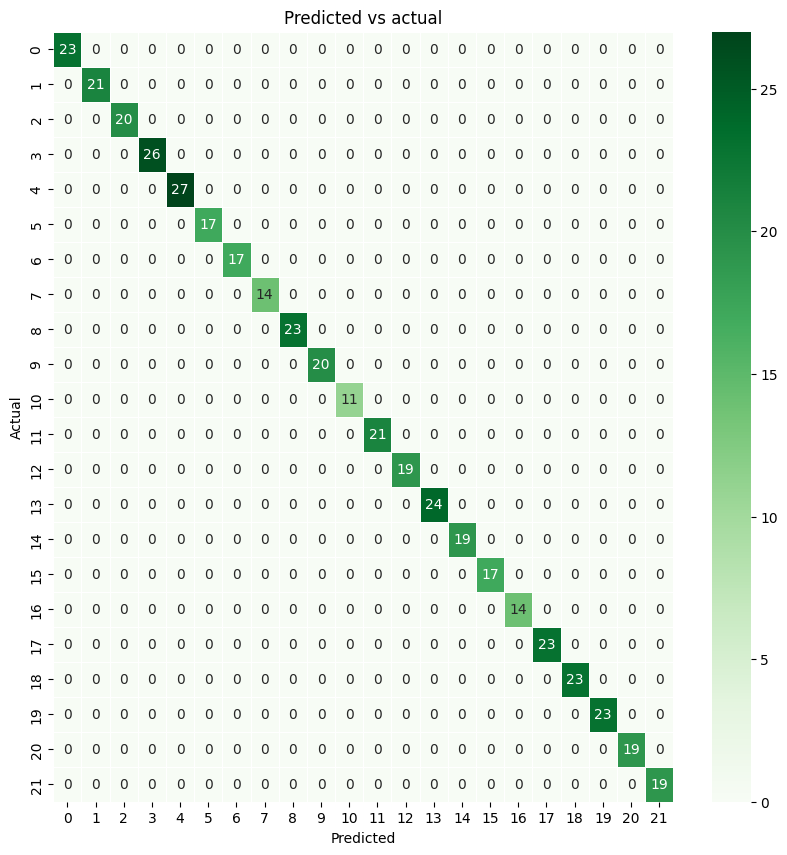

In [89]:
f, ax = plt.subplots(figsize=(10,10))
sns.heatmap(cm_knn, annot=True, linewidth=0.5, fmt=".0f",cmap='Greens', ax = ax)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Predicted vs actual')
plt.show()

In [75]:
# Save the best model as a .pkl file
model_filename = 'crop_recomendation_model.pkl'
joblib.dump(best_rf_model, model_filename)
# Crop Recommendation Dataset
print(f"\nBest model saved to {model_filename}")


Best model saved to crop_recomendation_model.pkl


In [81]:
import json

In [ ]:
# Create a dictionary mapping encoded labels to original crop names
label_mapping = {int(label): crop_name for label, crop_name in enumerate(le_full.classes_)}

In [ ]:
# Define the filename for the JSON file
json_filename = 'crop_class.json'


In [82]:

# Save the dictionary to a JSON file
with open(json_filename, 'w') as f:
    json.dump(label_mapping, f, indent=4)



In [83]:
print(f"Crop class mapping saved to {json_filename}")
print("Mapping content:")
print(json.dumps(label_mapping, indent=4))

Crop class mapping saved to crop_class.json
Mapping content:
{
    "0": "apple",
    "1": "banana",
    "2": "blackgram",
    "3": "chickpea",
    "4": "coconut",
    "5": "coffee",
    "6": "cotton",
    "7": "grapes",
    "8": "jute",
    "9": "kidneybeans",
    "10": "lentil",
    "11": "maize",
    "12": "mango",
    "13": "mothbeans",
    "14": "mungbean",
    "15": "muskmelon",
    "16": "orange",
    "17": "papaya",
    "18": "pigeonpeas",
    "19": "pomegranate",
    "20": "rice",
    "21": "watermelon"
}
